# Market Data Ingestion
Downloads 5 years of daily OHLCV data for AAPL, MSFT, NVDA, GOOGL, AMZN and the ^VIX index via yfinance.
All series are aligned on a common date index; gaps from market holidays are forward-filled.

In [1]:
import yfinance as yf
import pandas as pd
from datetime import date, timedelta

# ── Configuration ──────────────────────────────────────────────────────────────
TICKERS   = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "^VIX"]
END_DATE  = date.today()
START_DATE = END_DATE - timedelta(days=5 * 365)  # ~5 calendar years

print(f"Fetching data from {START_DATE} to {END_DATE} for: {TICKERS}")

# ── Download ───────────────────────────────────────────────────────────────────
# group_by='ticker' gives a MultiIndex (ticker, field) column structure.
# auto_adjust=True returns split/dividend-adjusted prices so OHLC are comparable
# across the full history.
raw = yf.download(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    group_by="ticker",
    auto_adjust=True,
    progress=True,
)

# ── Extract adjusted-close prices into a flat DataFrame ───────────────────────
# Each column corresponds to one instrument; the index is the shared trading-day
# calendar (union of all tickers' available dates).
close_frames = {}
for ticker in TICKERS:
    try:
        col_name = ticker.lstrip("^")          # strip ^ so column is "VIX"
        close_frames[col_name] = raw[ticker]["Close"]
    except KeyError:
        print(f"  WARNING: 'Close' not found for {ticker} — skipping.")

prices = pd.DataFrame(close_frames)

# ── Align & clean ──────────────────────────────────────────────────────────────
# 1. Ensure the index is a proper DatetimeIndex (yfinance usually returns one,
#    but an explicit cast is defensive and preserves tz-naivety consistently).
prices.index = pd.to_datetime(prices.index)
prices.index.name = "Date"

# 2. Sort chronologically (download should already be sorted, but be explicit).
prices.sort_index(inplace=True)

# 3. Forward-fill: propagates the last known price into any NaN slot caused by
#    holidays, exchange closures, or staggered listing dates.  A leading NaN
#    (before a ticker's first trading day) is left as-is intentionally — there
#    is no prior value to carry forward and back-filling would introduce look-
#    ahead bias.
prices.ffill(inplace=True)

# ── Diagnostics ────────────────────────────────────────────────────────────────
remaining_nulls = prices.isnull().sum()
print(f"\nShape after alignment: {prices.shape}  (rows × tickers)")
print(f"Date range : {prices.index[0].date()}  →  {prices.index[-1].date()}")
print(f"\nResidual NaNs per column (pre-first-trade gaps only):\n{remaining_nulls}")

# ── Preview ────────────────────────────────────────────────────────────────────
print("\nFirst five rows of cleaned price DataFrame:")
prices.head()

Fetching data from 2021-04-16 to 2026-04-15 for: ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', '^VIX']


[*********************100%***********************]  6 of 6 completed


Shape after alignment: (1254, 6)  (rows × tickers)
Date range : 2021-04-16  →  2026-04-14

Residual NaNs per column (pre-first-trade gaps only):
AAPL     0
MSFT     0
NVDA     0
GOOGL    0
AMZN     0
VIX      0
dtype: int64

First five rows of cleaned price DataFrame:


,AAPL,MSFT,NVDA,GOOGL,AMZN,VIX
Date,,,,,,
2021-04-16,130.671219,250.195602,15.872494,113.201881,169.972000,16.250000
2021-04-19,131.333511,248.276459,15.323127,113.549515,168.600494,17.290001
2021-04-20,129.648544,247.815887,15.133107,113.016426,166.734497,18.680000
2021-04-21,130.028412,250.041992,15.321883,112.983688,168.100998,17.500000
2021-04-22,128.508972,246.769958,14.812915,111.702782,165.451996,18.709999


## Amihud Illiquidity Metric

Calculates the Amihud (2002) illiquidity ratio for each equity:

$$\text{ILLIQ}_t = \frac{|R_t|}{P_t \times V_t}$$

where $R_t$ is the log return, $P_t$ is the adjusted closing price, and $V_t$ is share volume.
A natural-log transformation (`log1p`) is then applied to compress the heavy right tail
and stabilise variance for time-series modelling.  
^VIX is excluded — it is a volatility index with no tradeable share volume.

In [2]:
import numpy as np

# ── Equity universe (VIX has no share volume — excluded by design) ─────────────
EQUITY_TICKERS = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN"]

# ── Extract volume from the already-downloaded `raw` MultiIndex object ─────────
volume_frames = {}
for ticker in EQUITY_TICKERS:
    try:
        volume_frames[ticker] = raw[ticker]["Volume"]
    except KeyError:
        print(f"  WARNING: 'Volume' not found for {ticker} — skipping.")

volume = pd.DataFrame(volume_frames)
volume.index = pd.to_datetime(volume.index)
volume.index.name = "Date"
volume.sort_index(inplace=True)
volume.ffill(inplace=True)

# Isolate close prices for equities only (drop VIX column).
equity_prices = prices[EQUITY_TICKERS].copy()

# ── Tiny floor constant ────────────────────────────────────────────────────────
# Raw Amihud scores sit around 1e-12. log1p(x) ≈ x for x << 1, so it rounded
# every score to zero. We switch to log(raw_illiq + EPS) which maps 1e-12 to
# roughly -27.6 — a finite, meaningful negative number on the log scale.
# EPS = 1e-25 is well below the smallest observed score (~1e-14 for large-caps)
# so it acts purely as a -inf guard and does not distort the distribution.
EPS = 1e-25


def amihud_illiquidity(
    close: pd.Series,
    vol: pd.Series,
    log_transform: bool = True,
) -> pd.Series:
    """
    Compute the Amihud (2002) illiquidity ratio for a single instrument.

    Parameters
    ----------
    close         : pd.Series — adjusted closing price time series.
    vol           : pd.Series — daily share volume time series.
    log_transform : bool      — if True, apply log(raw + EPS) to map the
                                distribution to a usable numeric range for
                                time-series modelling.

    Returns
    -------
    pd.Series of illiquidity scores aligned to the input index.

    Notes
    -----
    * Log returns are used for |R_t| rather than simple returns; they are
      additive over time and better-behaved for downstream regression models.
    * Dollar volume (P_t * V_t) normalises raw share counts into USD notional,
      making scores comparable across tickers with different price levels.
    * Days where close <= 0 or volume == 0 produce undefined ratios; they are
      replaced with NaN and forward-filled to avoid distorting the time series.
    * log1p was previously used but rounds to zero when raw scores are ~1e-12
      because log1p(x) ≈ x for x << 1. log(x + EPS) correctly maps 1e-12 to
      ≈ -27.6, giving the series real variance for PCA and ARIMAX modelling.
    """
    # Log return: ln(P_t / P_{t-1}); first observation becomes NaN.
    log_ret = np.log(close / close.shift(1))
    abs_ret = log_ret.abs()

    # Dollar volume denominator.
    dollar_vol = close * vol

    # Raw Amihud ratio; mask degenerate rows (zero/missing denominator).
    raw_illiq = abs_ret / dollar_vol
    raw_illiq[dollar_vol <= 0] = np.nan
    raw_illiq.ffill(inplace=True)

    if log_transform:
        # log(x + EPS): EPS guards against log(0) = -inf on zero-return days
        # while having negligible effect on scores in the 1e-14 to 1e-10 range.
        return np.log(raw_illiq + EPS)
    return raw_illiq


# ── Apply to all equity tickers ────────────────────────────────────────────────
illiq_scores = pd.DataFrame(
    {
        ticker: amihud_illiquidity(
            close=equity_prices[ticker],
            vol=volume[ticker],
            log_transform=True,
        )
        for ticker in EQUITY_TICKERS
    }
)
illiq_scores.index.name = "Date"

# ── Diagnostics ────────────────────────────────────────────────────────────────
print("Amihud Log-Illiquidity Scores — descriptive statistics:")
print(illiq_scores.describe().round(4))
print(f"\nResidual NaNs:\n{illiq_scores.isnull().sum()}")

# ── Preview ────────────────────────────────────────────────────────────────────
print("\nFirst five rows of log-transformed Amihud illiquidity scores:")
illiq_scores.head()

Amihud Log-Illiquidity Scores — descriptive statistics:
            AAPL       MSFT       NVDA      GOOGL       AMZN
count  1253.0000  1253.0000  1253.0000  1253.0000  1253.0000
mean    -28.1199   -27.8125   -27.8411   -26.9845   -27.5514
std       1.7982     1.4158     1.7519     1.6267     1.8486
min     -57.5646   -57.5646   -57.5646   -57.5646   -57.5646
25%     -28.6151   -28.3827   -28.4962   -27.5142   -28.0420
50%     -27.8386   -27.5787   -27.6902   -26.7383   -27.2257
75%     -27.2942   -26.9856   -26.9003   -26.1891   -26.7154
max     -26.0294   -25.6518   -25.1339   -24.8970   -25.4627

Residual NaNs:
AAPL     1
MSFT     1
NVDA     1
GOOGL    1
AMZN     1
dtype: int64

First five rows of log-transformed Amihud illiquidity scores:


,AAPL,MSFT,NVDA,GOOGL,AMZN
Date,,,,,
2021-04-16,NaN,NaN,NaN,NaN,NaN
2021-04-19,-28.526613,-27.341123,-25.893344,-27.745880,-27.757066
2021-04-20,-27.581782,-28.598879,-26.727690,-27.006047,-27.390141
2021-04-21,-28.749375,-27.233367,-26.313941,-29.833694,-27.537576
2021-04-22,-27.552587,-26.896440,-25.525676,-26.189451,-27.010396


## Small/Mid-Cap Universe — Amihud Illiquidity Pipeline

A second universe of five high-volatility, lower-liquidity names is run through the identical Amihud pipeline:

| Ticker | Name | Sector note |
|--------|------|-------------|
| MARA | Marathon Digital | Bitcoin miner — volume driven by crypto sentiment |
| RIOT | Riot Platforms | Bitcoin miner — near-identical driver to MARA |
| SMCI | Super Micro Computer | Server hardware — high beta to AI capex cycle |
| SOFI | SoFi Technologies | Fintech neobank — rate-sensitive, retail-heavy float |
| RIVN | Rivian Automotive | EV OEM — IPO'd Nov 2021, so ~3.5 years of history |

Because RIVN listed mid-window, its pre-IPO rows are NaN and are left as-is (no back-fill). The comparison chart aligns all series on the intersection of available dates.

In [3]:
# ── Small/mid-cap universe ─────────────────────────────────────────────────────
SC_TICKERS = ["MARA", "RIOT", "SMCI", "SOFI", "RIVN"]

print(f"Fetching small-cap data from {START_DATE} to {END_DATE} for: {SC_TICKERS}")

raw_sc = yf.download(
    tickers=SC_TICKERS,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    group_by="ticker",
    auto_adjust=True,
    progress=True,
)

# ── Extract close and volume ───────────────────────────────────────────────────
sc_close_frames  = {}
sc_volume_frames = {}

for ticker in SC_TICKERS:
    try:
        sc_close_frames[ticker]  = raw_sc[ticker]["Close"]
        sc_volume_frames[ticker] = raw_sc[ticker]["Volume"]
    except KeyError:
        print(f"  WARNING: data not found for {ticker} — skipping.")

sc_prices = pd.DataFrame(sc_close_frames)
sc_volume = pd.DataFrame(sc_volume_frames)

for df in (sc_prices, sc_volume):
    df.index = pd.to_datetime(df.index)
    df.index.name = "Date"
    df.sort_index(inplace=True)
    df.ffill(inplace=True)
    # Do NOT back-fill: RIVN pre-IPO rows stay NaN to avoid look-ahead bias.

# ── Run identical Amihud pipeline on small-caps ────────────────────────────────
# amihud_illiquidity() and EPS are defined in the mega-cap cell above.
illiq_scores_sc = pd.DataFrame(
    {
        ticker: amihud_illiquidity(
            close=sc_prices[ticker],
            vol=sc_volume[ticker],
            log_transform=True,
        )
        for ticker in SC_TICKERS
    }
)
illiq_scores_sc.index.name = "Date"

# ── Diagnostics ────────────────────────────────────────────────────────────────
print("\nSmall-Cap Amihud Log-Illiquidity — descriptive statistics:")
print(illiq_scores_sc.describe().round(4))
print(f"\nResidual NaNs (RIVN pre-IPO gap expected):\n{illiq_scores_sc.isnull().sum()}")

# ── Side-by-side describe: mega-cap vs small-cap ──────────────────────────────
compare_stats = pd.DataFrame({
    "Mega mean" : illiq_scores.mean(),
    "Mega std"  : illiq_scores.std(),
    "SC mean"   : illiq_scores_sc.mean(),
    "SC std"    : illiq_scores_sc.std(),
}).round(4)

print("\nMega-cap vs Small-cap — mean and std of log-illiquidity:")
print(compare_stats)

[                       0%                       ]

Fetching small-cap data from 2021-04-16 to 2026-04-15 for: ['MARA', 'RIOT', 'SMCI', 'SOFI', 'RIVN']


[*********************100%***********************]  5 of 5 completed



Small-Cap Amihud Log-Illiquidity — descriptive statistics:
            MARA       RIOT       SMCI       SOFI       RIVN
count  1253.0000  1253.0000  1253.0000  1253.0000  1108.0000
mean    -23.6146   -22.8957   -23.3987   -23.9568   -24.0658
std       3.0427     2.7155     2.5302     3.2407     2.4880
min     -57.5646   -57.5646   -57.5646   -57.5646   -57.5646
25%     -24.1541   -23.4051   -25.0247   -24.4960   -24.4626
50%     -23.3057   -22.6103   -23.8556   -23.5476   -23.6992
75%     -22.4819   -21.9248   -21.2921   -22.8928   -23.1368
max     -19.6834   -19.5081   -18.6011   -18.5471   -22.0351

Residual NaNs (RIVN pre-IPO gap expected):
MARA      1
RIOT      1
SMCI      1
SOFI      1
RIVN    146
dtype: int64

Mega-cap vs Small-cap — mean and std of log-illiquidity:
       Mega mean  Mega std  SC mean  SC std
AAPL    -28.1199    1.7982      NaN     NaN
AMZN    -27.5514    1.8486      NaN     NaN
GOOGL   -26.9845    1.6267      NaN     NaN
MARA         NaN       NaN -23.6146  3.0

## Exploratory Data Analysis

### Visualisation 1 — Correlation Heatmap of Log-Illiquidity Scores
Pearson correlations across the five equities reveal whether illiquidity shocks are idiosyncratic or sector-wide.  
High off-diagonal values suggest common liquidity drivers (e.g. macro stress, index rebalancing).

### Visualisation 2 — Average Tech Illiquidity vs. VIX (Dual-Axis)
Overlays the equal-weighted mean log-illiquidity of the five stocks against the VIX closing level.  
A strong co-movement would support using VIX as a leading liquidity-stress indicator in the model.

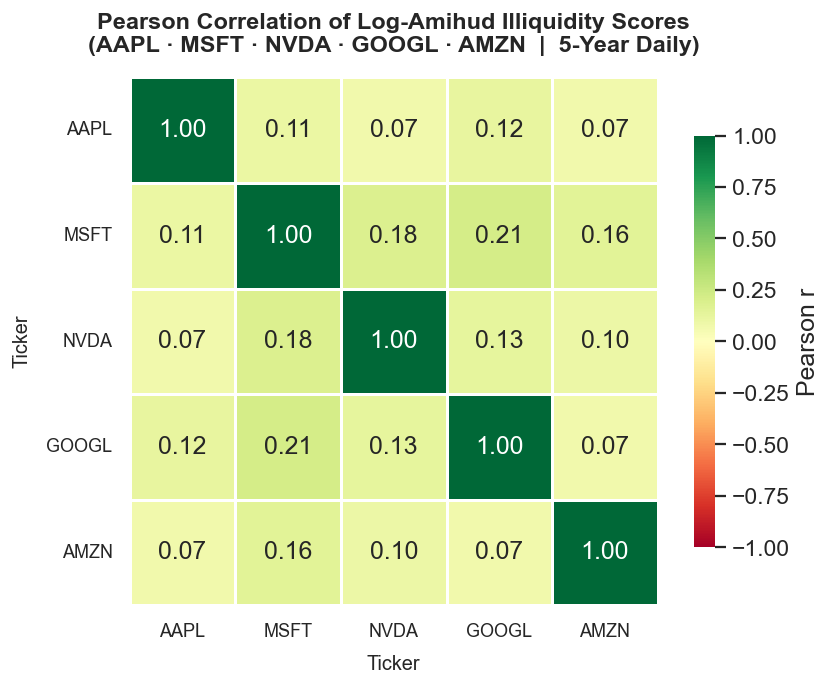

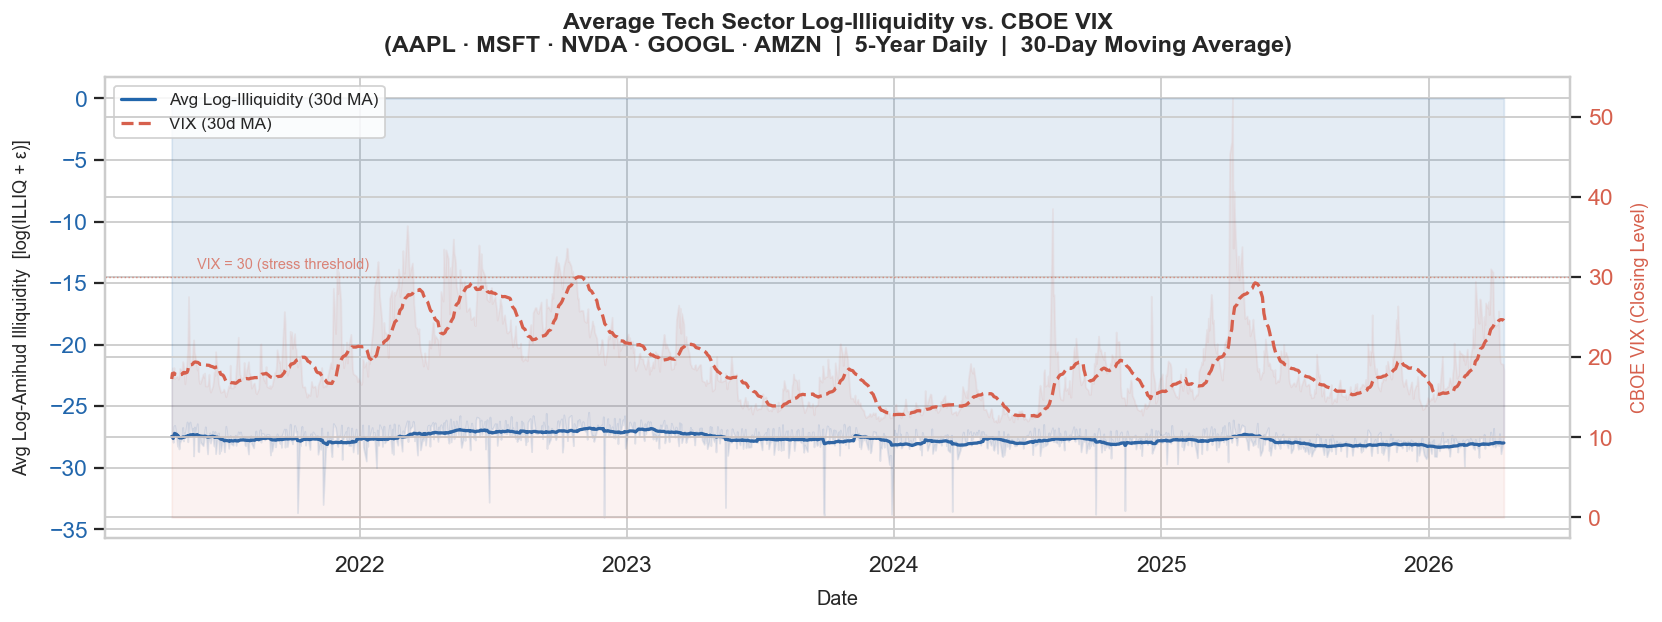

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Global aesthetics ──────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams["figure.dpi"] = 130

# ══════════════════════════════════════════════════════════════════════════════
# VISUALISATION 1 — Pearson Correlation Heatmap of Log-Illiquidity Scores
# ══════════════════════════════════════════════════════════════════════════════
corr_matrix = illiq_scores.corr(method="pearson")

fig1, ax1 = plt.subplots(figsize=(7, 5.5))

sns.heatmap(
    corr_matrix,
    ax=ax1,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.78, "label": "Pearson r"},
)

ax1.set_title(
    "Pearson Correlation of Log-Amihud Illiquidity Scores\n"
    "(AAPL · MSFT · NVDA · GOOGL · AMZN  |  5-Year Daily)",
    fontsize=13, fontweight="bold", pad=14,
)
ax1.set_xlabel("Ticker", fontsize=11, labelpad=8)
ax1.set_ylabel("Ticker", fontsize=11, labelpad=8)
ax1.tick_params(axis="both", labelsize=10, rotation=0)

fig1.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# VISUALISATION 2 — Dual-Axis: Average Tech Illiquidity vs. VIX
# ══════════════════════════════════════════════════════════════════════════════

avg_illiq = illiq_scores.mean(axis=1).rename("Avg Log-Illiquidity")
vix_series = prices["VIX"].copy()

combined = pd.concat([avg_illiq, vix_series], axis=1, join="inner")
combined.columns = ["Avg Log-Illiquidity", "VIX"]
combined.dropna(inplace=True)

WINDOW = 30
illiq_smooth = combined["Avg Log-Illiquidity"].rolling(WINDOW, min_periods=1).mean()
vix_smooth   = combined["VIX"].rolling(WINDOW, min_periods=1).mean()

fig2, ax_left = plt.subplots(figsize=(13, 5))
ax_right = ax_left.twinx()

ILLIQ_COLOR = "#2166AC"
VIX_COLOR   = "#D6604D"

ax_left.fill_between(combined.index, combined["Avg Log-Illiquidity"],
                     alpha=0.12, color=ILLIQ_COLOR, label="_nolegend_")
ax_left.plot(illiq_smooth.index, illiq_smooth,
             color=ILLIQ_COLOR, linewidth=1.8,
             label=f"Avg Log-Illiquidity ({WINDOW}d MA)")

ax_right.fill_between(combined.index, combined["VIX"],
                      alpha=0.08, color=VIX_COLOR, label="_nolegend_")
ax_right.plot(vix_smooth.index, vix_smooth,
              color=VIX_COLOR, linewidth=1.8, linestyle="--",
              label=f"VIX ({WINDOW}d MA)")

ax_left.set_title(
    "Average Tech Sector Log-Illiquidity vs. CBOE VIX\n"
    "(AAPL · MSFT · NVDA · GOOGL · AMZN  |  5-Year Daily  |  30-Day Moving Average)",
    fontsize=13, fontweight="bold", pad=14,
)
ax_left.set_xlabel("Date", fontsize=11, labelpad=8)
ax_left.set_ylabel("Avg Log-Amihud Illiquidity  [log(ILLIQ + ε)]", fontsize=10, labelpad=10)
ax_right.set_ylabel("CBOE VIX (Closing Level)", fontsize=10, labelpad=10, color=VIX_COLOR)

ax_left.tick_params(axis="y", labelcolor=ILLIQ_COLOR)
ax_right.tick_params(axis="y", labelcolor=VIX_COLOR)

ax_left.xaxis.set_major_locator(mdates.YearLocator())
ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_left.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
plt.setp(ax_left.xaxis.get_majorticklabels(), rotation=0, ha="center")

lines_left,  labels_left  = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right,
               loc="upper left", fontsize=9.5, framealpha=0.85)

ax_right.axhline(30, color=VIX_COLOR, linewidth=0.8, linestyle=":", alpha=0.6)
ax_right.annotate(
    "VIX = 30 (stress threshold)",
    xy=(combined.index[int(len(combined) * 0.02)], 31),
    fontsize=8, color=VIX_COLOR, alpha=0.75,
)

fig2.tight_layout()
plt.show()

Average log-illiquidity levels by universe:
  Mega-cap  mean = -27.662  std = 0.918
  Small-cap mean = -23.548  std = 1.495

  Small-caps are ~4.11 log-units more illiquid on average.



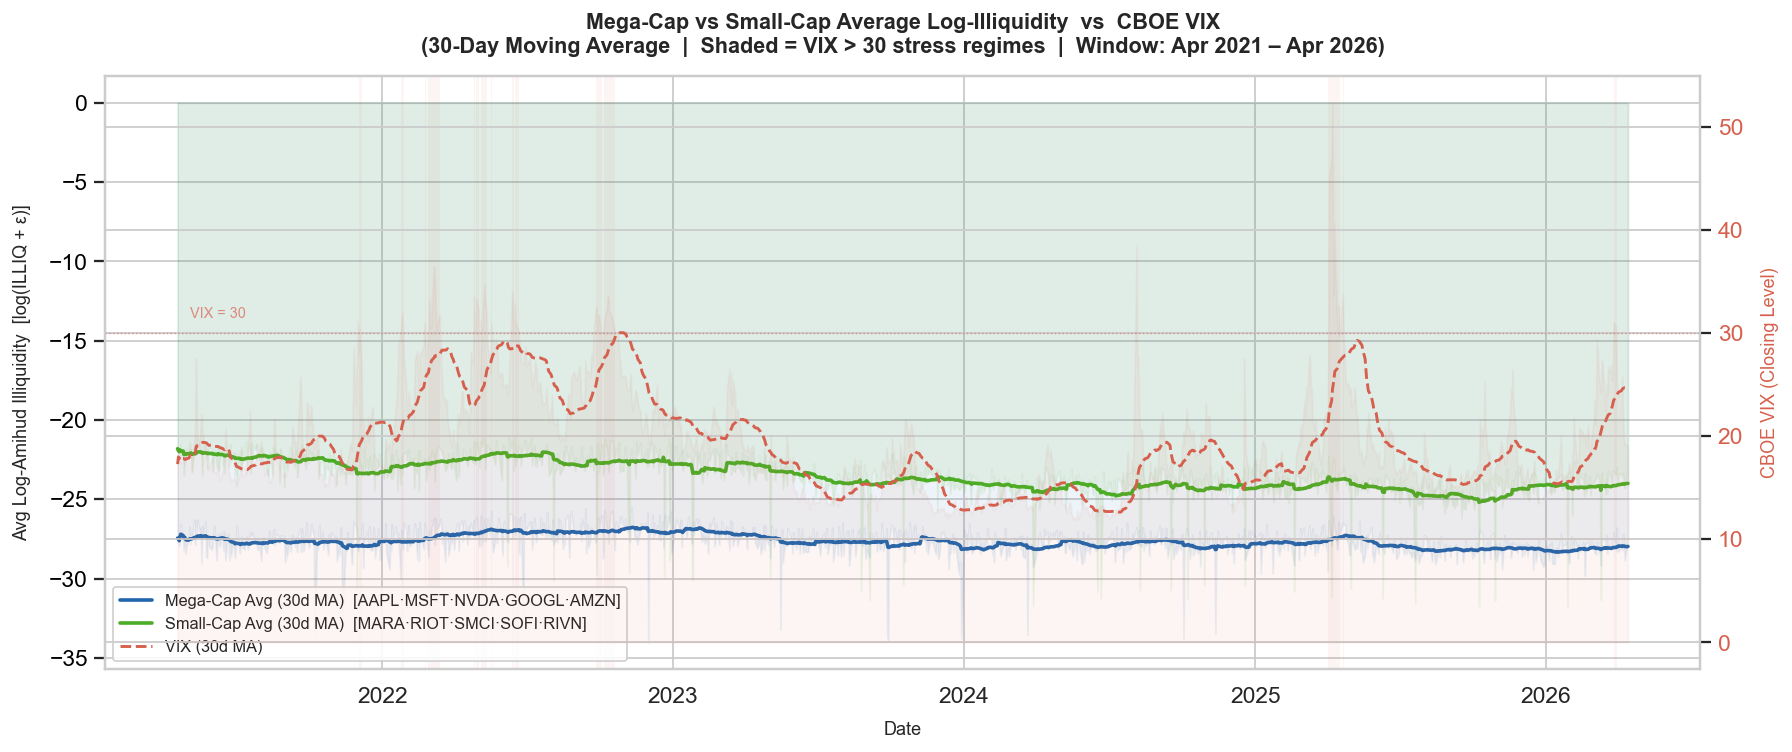

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# VISUALISATION 3 — Mega-Cap vs Small-Cap Avg Illiquidity vs VIX
# Three series on two axes:
#   Left  — both illiquidity averages (same log scale → directly comparable)
#   Right — VIX
# ══════════════════════════════════════════════════════════════════════════════

WINDOW = 30

# Equal-weighted averages for each universe.
avg_mega = illiq_scores.mean(axis=1).rename("Mega-Cap Avg")
avg_sc   = illiq_scores_sc.mean(axis=1).rename("Small-Cap Avg")

# Align all three series on a common date index (inner join drops RIVN pre-IPO
# rows so the small-cap average is not dragged down by NaN before Nov 2021).
trio = pd.concat([avg_mega, avg_sc, prices["VIX"]], axis=1, join="inner").dropna()
trio.columns = ["Mega-Cap Avg", "Small-Cap Avg", "VIX"]

# Rolling smoothing — suppress daily noise, preserve structural moves.
mega_smooth = trio["Mega-Cap Avg"].rolling(WINDOW, min_periods=1).mean()
sc_smooth   = trio["Small-Cap Avg"].rolling(WINDOW, min_periods=1).mean()
vix_smooth  = trio["VIX"].rolling(WINDOW, min_periods=1).mean()

# ── Print level summary so the scale difference is obvious in the output ───────
print("Average log-illiquidity levels by universe:")
print(f"  Mega-cap  mean = {trio['Mega-Cap Avg'].mean():.3f}  "
      f"std = {trio['Mega-Cap Avg'].std():.3f}")
print(f"  Small-cap mean = {trio['Small-Cap Avg'].mean():.3f}  "
      f"std = {trio['Small-Cap Avg'].std():.3f}")
print(f"\n  Small-caps are ~{trio['Small-Cap Avg'].mean() - trio['Mega-Cap Avg'].mean():.2f} "
      f"log-units more illiquid on average.\n")

# ── Colours ───────────────────────────────────────────────────────────────────
MEGA_COLOR  = "#2166AC"   # blue  — mega-caps (existing)
SC_COLOR    = "#4DAC26"   # green — small-caps
VIX_COLOR   = "#D6604D"   # red   — VIX (existing)

fig, ax_illiq = plt.subplots(figsize=(14, 6))
ax_vix = ax_illiq.twinx()

# ── Left axis — both illiquidity series ───────────────────────────────────────
# Raw series as translucent fills to show day-to-day volatility.
ax_illiq.fill_between(trio.index, trio["Mega-Cap Avg"],
                      alpha=0.08, color=MEGA_COLOR)
ax_illiq.fill_between(trio.index, trio["Small-Cap Avg"],
                      alpha=0.08, color=SC_COLOR)

# Smoothed lines as the primary readable signal.
ax_illiq.plot(mega_smooth.index, mega_smooth,
              color=MEGA_COLOR, linewidth=2.0,
              label=f"Mega-Cap Avg ({WINDOW}d MA)  [AAPL·MSFT·NVDA·GOOGL·AMZN]")
ax_illiq.plot(sc_smooth.index, sc_smooth,
              color=SC_COLOR, linewidth=2.0,
              label=f"Small-Cap Avg ({WINDOW}d MA)  [MARA·RIOT·SMCI·SOFI·RIVN]")

# ── Right axis — VIX ──────────────────────────────────────────────────────────
ax_vix.fill_between(trio.index, trio["VIX"],
                    alpha=0.06, color=VIX_COLOR)
ax_vix.plot(vix_smooth.index, vix_smooth,
            color=VIX_COLOR, linewidth=1.6, linestyle="--",
            label=f"VIX ({WINDOW}d MA)")

# Stress threshold reference line.
ax_vix.axhline(30, color=VIX_COLOR, linewidth=0.8, linestyle=":", alpha=0.55)
ax_vix.annotate("VIX = 30",
                xy=(trio.index[int(len(trio) * 0.01)], 31.5),
                fontsize=8, color=VIX_COLOR, alpha=0.7)

# ── Shade VIX > 30 stress regimes across the full chart ───────────────────────
# This makes the co-movement hypothesis visually testable at a glance.
stress = trio["VIX"] > 30
in_stress = False
stress_start = None
for date, flag in stress.items():
    if flag and not in_stress:
        stress_start = date
        in_stress = True
    elif not flag and in_stress:
        ax_illiq.axvspan(stress_start, date,
                         color=VIX_COLOR, alpha=0.06, linewidth=0)
        in_stress = False
if in_stress:   # close any open stress period at end of series
    ax_illiq.axvspan(stress_start, trio.index[-1],
                     color=VIX_COLOR, alpha=0.06, linewidth=0)

# ── Labels and formatting ──────────────────────────────────────────────────────
ax_illiq.set_title(
    "Mega-Cap vs Small-Cap Average Log-Illiquidity  vs  CBOE VIX\n"
    f"(30-Day Moving Average  |  Shaded = VIX > 30 stress regimes  |  "
    f"Window: {trio.index[0].strftime('%b %Y')} – {trio.index[-1].strftime('%b %Y')})",
    fontsize=12, fontweight="bold", pad=13,
)
ax_illiq.set_xlabel("Date", fontsize=10, labelpad=8)
ax_illiq.set_ylabel("Avg Log-Amihud Illiquidity  [log(ILLIQ + ε)]",
                    fontsize=10, labelpad=10)
ax_vix.set_ylabel("CBOE VIX (Closing Level)",
                  fontsize=10, labelpad=10, color=VIX_COLOR)

ax_illiq.tick_params(axis="y", labelcolor="black")
ax_vix.tick_params(axis="y", labelcolor=VIX_COLOR)

ax_illiq.xaxis.set_major_locator(mdates.YearLocator())
ax_illiq.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_illiq.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
plt.setp(ax_illiq.xaxis.get_majorticklabels(), rotation=0, ha="center")

# Unified legend combining both axes.
lines_l, labels_l = ax_illiq.get_legend_handles_labels()
lines_r, labels_r = ax_vix.get_legend_handles_labels()
ax_illiq.legend(lines_l + lines_r, labels_l + labels_r,
                loc="lower left", fontsize=9, framealpha=0.88)

fig.tight_layout()
plt.show()

## Time-Series Modelling — ARIMAX on the PC1 Liquidity Factor

**Pipeline:**
1. **PCA** — reduce the five log-illiquidity series to a single latent factor (PC1) that captures the dominant co-movement.
2. **ADF Test** — verify PC1 is stationary before fitting any ARIMA-family model; differencing order `d` is set accordingly.
3. **AIC Grid Search** — exhaustive search over `p ∈ [0,3]`, `d ∈ [0,1]`, `q ∈ [0,3]` to find the optimal ARIMAX order.
4. **ARIMAX Fit** — PC1 is the endogenous target; the daily VIX closing level is the exogenous regressor.
5. **Actual vs. Predicted Plot** — in-sample fit visualised over the most recent 60 trading days.

── PCA Explained Variance ──────────────────────────────────────────
  PC1: 30.10%  ◀ selected
  PC2: 18.97%  
  PC3: 18.45%  
  PC4: 17.30%  
  PC5: 15.18%  

  PC1 captures 30.10% of total log-illiquidity variance.

── Augmented Dickey-Fuller Test on PC1 ─────────────────────────────
  Test Statistic : -3.5240
  p-value        : 0.0074
  Lags Used      : 19
  Observations   : 1233
  Critical Values:
    1%: -3.4357
    5%: -2.8639
    10%: -2.5680

  RESULT: Reject H₀ — PC1 is STATIONARY (d = 0 is valid).

── Modelling window: 2021-04-19 → 2026-04-14
   Observations: 1253

── ARIMAX AIC Grid Search ──────────────────────────────────────────
  Search space: p ∈ [0, 1, 2, 3], d ∈ [0, 1], q ∈ [0, 1, 2, 3]
  Total candidates: 32

  Top 10 models by AIC:
 p  d  q         AIC
 0  1  1 3856.329262
 0  1  2 3857.208568
 1  1  1 3857.279932
 0  1  3 3857.900446
 2  1  1 3858.114354
 3  1  1 3858.437594
 2  1  3 3859.836100
 1  0  1 3860.173862
 1  1  2 3860.314616
 2  0  1 3861.087419

  ✔ Op

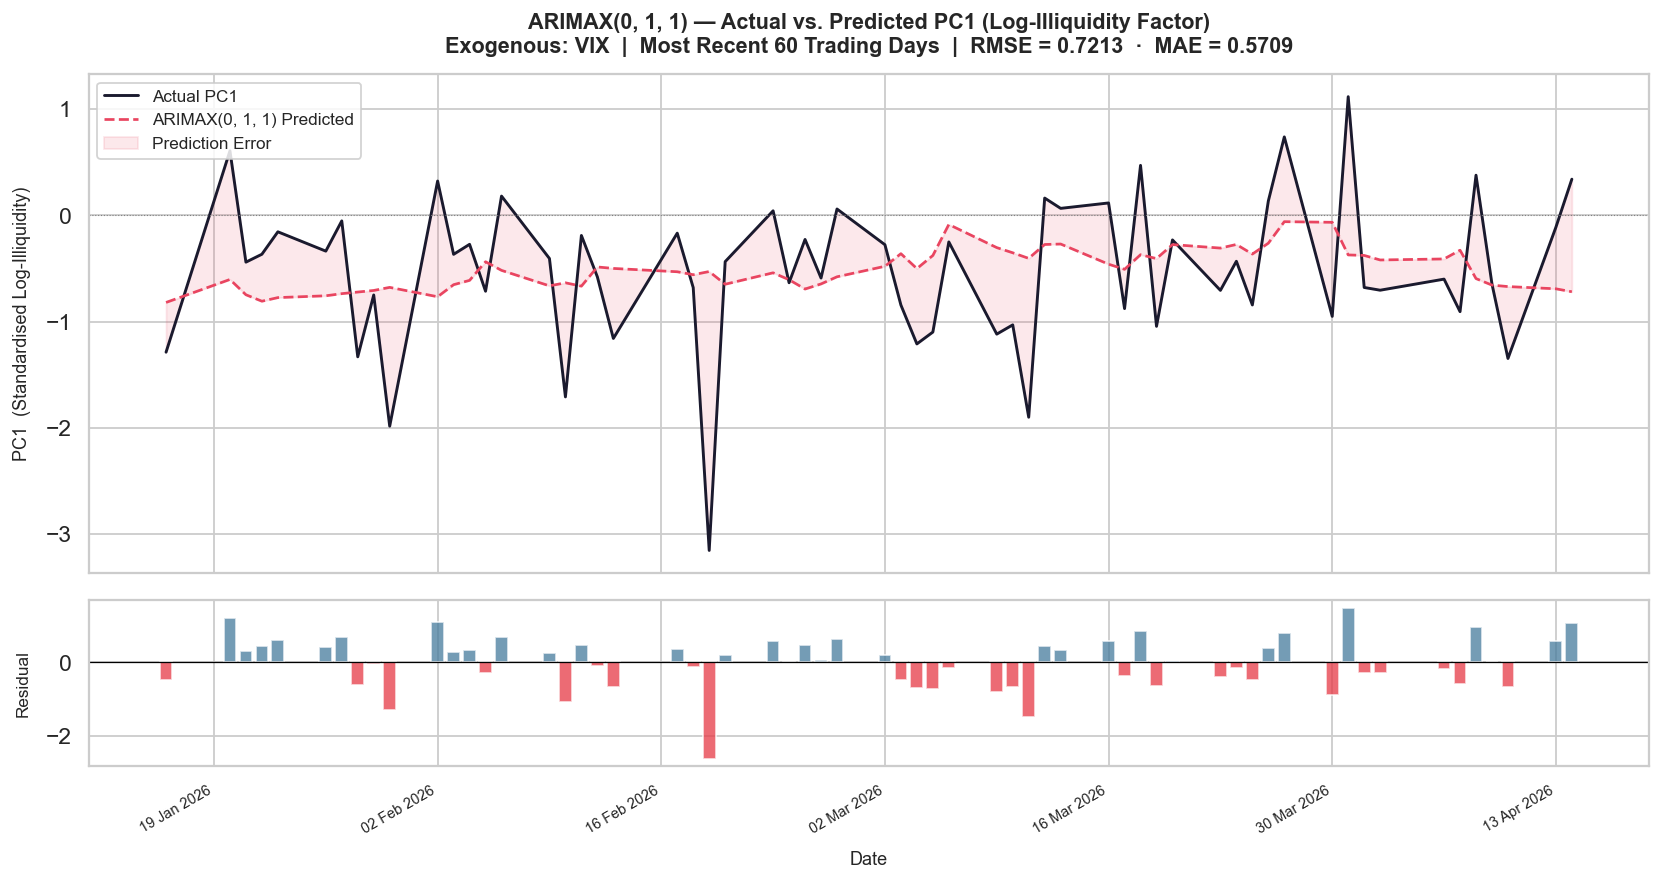

In [6]:
import itertools
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")   # suppress convergence noise during grid search

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — PCA: Reduce five log-illiquidity series → PC1
# ══════════════════════════════════════════════════════════════════════════════
# Drop any rows with NaN before scaling (the first row is always NaN because
# log returns require a prior observation).
illiq_clean = illiq_scores.dropna()

# Z-score each column so PCA is not dominated by the ticker with the largest
# absolute illiquidity level (NVDA at high price tends to have smallest raw
# ILLIQ, AAPL/MSFT tend to be larger — standardisation neutralises this).
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(illiq_clean)

pca = PCA(n_components=len(EQUITY_TICKERS))
pca.fit(X_scaled)

# PC1 is the first principal component — the linear combination that explains
# the largest share of cross-sectional variance in log-illiquidity.
pc1 = pd.Series(
    pca.transform(X_scaled)[:, 0],
    index=illiq_clean.index,
    name="PC1_LogIlliquidity",
)

explained = pca.explained_variance_ratio_
print("── PCA Explained Variance ──────────────────────────────────────────")
for i, ev in enumerate(explained, 1):
    print(f"  PC{i}: {ev:.2%}  {'◀ selected' if i == 1 else ''}")
print(f"\n  PC1 captures {explained[0]:.2%} of total log-illiquidity variance.\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Augmented Dickey-Fuller Test for Stationarity on PC1
# ══════════════════════════════════════════════════════════════════════════════
# H₀: unit root present (non-stationary).  Reject H₀ if p-value < 0.05.
adf_stat, adf_pval, adf_lags, adf_nobs, adf_crit, _ = adfuller(pc1, autolag="AIC")

print("── Augmented Dickey-Fuller Test on PC1 ─────────────────────────────")
print(f"  Test Statistic : {adf_stat:.4f}")
print(f"  p-value        : {adf_pval:.4f}")
print(f"  Lags Used      : {adf_lags}")
print(f"  Observations   : {adf_nobs}")
print("  Critical Values:")
for level, cv in adf_crit.items():
    print(f"    {level}: {cv:.4f}")

if adf_pval < 0.05:
    print("\n  RESULT: Reject H₀ — PC1 is STATIONARY (d = 0 is valid).")
    adf_d_max = 1   # allow d ∈ {0, 1} in the grid; model may still pick d=1
else:
    print("\n  RESULT: Fail to reject H₀ — PC1 is NON-STATIONARY (d ≥ 1 required).")
    adf_d_max = 2

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Align PC1 with VIX on a common date index
# ══════════════════════════════════════════════════════════════════════════════
vix_exog = prices["VIX"].reindex(pc1.index).ffill()

# Inner-join ensures every row has both an endogenous and exogenous value.
ts_df = pd.concat([pc1, vix_exog], axis=1, join="inner").dropna()
ts_df.columns = ["PC1", "VIX"]

endog = ts_df["PC1"]
exog  = ts_df[["VIX"]]

print(f"\n── Modelling window: {ts_df.index[0].date()} → {ts_df.index[-1].date()}")
print(f"   Observations: {len(ts_df)}\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — AIC Grid Search for Optimal ARIMAX(p, d, q) Order
# ══════════════════════════════════════════════════════════════════════════════
p_vals = range(0, 4)
d_vals = range(0, adf_d_max + 1)
q_vals = range(0, 4)

aic_records = []
best_aic    = np.inf
best_order  = (1, 0, 0)   # sensible default if all fits fail

print("── ARIMAX AIC Grid Search ──────────────────────────────────────────")
print(f"  Search space: p ∈ {list(p_vals)}, d ∈ {list(d_vals)}, q ∈ {list(q_vals)}")
print(f"  Total candidates: {len(p_vals) * len(d_vals) * len(q_vals)}\n")

for p, d, q in itertools.product(p_vals, d_vals, q_vals):
    # (0,0,0) with exog is just an OLS regression — valid but a useful baseline.
    try:
        fit = ARIMA(endog, exog=exog, order=(p, d, q)).fit(
            method_kwargs={"warn_convergence": False}
        )
        aic_records.append({"p": p, "d": d, "q": q, "AIC": fit.aic})
        if fit.aic < best_aic:
            best_aic   = fit.aic
            best_order = (p, d, q)
    except Exception:
        # Some (p,d,q) combinations are not identifiable — skip silently.
        continue

aic_table = (
    pd.DataFrame(aic_records)
      .sort_values("AIC")
      .reset_index(drop=True)
)

print("  Top 10 models by AIC:")
print(aic_table.head(10).to_string(index=False))
print(f"\n  ✔ Optimal order selected: ARIMAX{best_order}  (AIC = {best_aic:.4f})\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Fit the Optimal ARIMAX Model
# ══════════════════════════════════════════════════════════════════════════════
best_model = ARIMA(endog, exog=exog, order=best_order).fit()

print("── ARIMAX Model Summary ────────────────────────────────────────────")
print(best_model.summary())

# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — Actual vs. Predicted: Most Recent 60 Trading Days
# ══════════════════════════════════════════════════════════════════════════════
LOOKBACK = 60

actual    = endog.iloc[-LOOKBACK:]
predicted = best_model.fittedvalues.iloc[-LOOKBACK:]
residuals = actual - predicted

rmse = np.sqrt((residuals ** 2).mean())
mae  = residuals.abs().mean()

print(f"\n── In-Sample Fit Metrics (last {LOOKBACK} days) ──────────────────────────")
print(f"  RMSE : {rmse:.6f}")
print(f"  MAE  : {mae:.6f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax_main, ax_resid) = plt.subplots(
    2, 1, figsize=(13, 7),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)

# — Main panel: actual vs. predicted —
ax_main.plot(
    actual.index, actual.values,
    color="#1a1a2e", linewidth=1.6,
    label="Actual PC1",
)
ax_main.plot(
    predicted.index, predicted.values,
    color="#e94560", linewidth=1.5, linestyle="--",
    label=f"ARIMAX{best_order} Predicted",
)
ax_main.fill_between(
    actual.index, actual.values, predicted.values,
    alpha=0.12, color="#e94560", label="Prediction Error",
)

ax_main.set_title(
    f"ARIMAX{best_order} — Actual vs. Predicted PC1 (Log-Illiquidity Factor)\n"
    f"Exogenous: VIX  |  Most Recent {LOOKBACK} Trading Days  |  "
    f"RMSE = {rmse:.4f}  ·  MAE = {mae:.4f}",
    fontsize=12, fontweight="bold", pad=12,
)
ax_main.set_ylabel("PC1  (Standardised Log-Illiquidity)", fontsize=10, labelpad=8)
ax_main.legend(loc="upper left", fontsize=9.5, framealpha=0.85)
ax_main.axhline(0, color="grey", linewidth=0.6, linestyle=":")

# — Residual panel —
ax_resid.bar(
    residuals.index, residuals.values,
    color=np.where(residuals.values >= 0, "#457b9d", "#e63946"),
    width=0.8, alpha=0.75,
)
ax_resid.axhline(0, color="black", linewidth=0.7)
ax_resid.set_ylabel("Residual", fontsize=9.5, labelpad=8)
ax_resid.set_xlabel("Date", fontsize=10, labelpad=8)

# — Date formatting —
ax_resid.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
ax_resid.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
plt.setp(ax_resid.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

fig.tight_layout()
plt.show()

## ARIMAX(0,1,1) — Small-Cap PC1 vs Mega-Cap Model Comparison

The identical `ARIMAX(0,1,1)` specification is fitted on the small-cap PC1 factor with VIX as the exogenous regressor.

**Hypothesis:** small-cap illiquidity co-moves more strongly with VIX (as shown in Visualisation 3), so VIX should explain a greater share of variance in the small-cap PC1, producing **lower RMSE and MAE** than the mega-cap fit.

── Small-Cap PCA Explained Variance ───────────────────────────────────
  PC1: 28.47%  ◀ selected
  PC2: 20.00%  
  PC3: 19.31%  
  PC4: 16.87%  
  PC5: 15.35%  

  SC_PC1 captures 28.47% of small-cap variance (vs 30.10% for mega-caps).

── ADF Test on SC_PC1 ─────────────────────────────────────────────────────────
  Test Statistic : -2.4863
  p-value        : 0.1188
  Lags Used      : 14
  Critical Value (1%): -3.4363
  Critical Value (5%): -2.8642
  Critical Value (10%): -2.5682

  RESULT: Fail to reject H₀ — SC_PC1 is NON-STATIONARY.

── Small-Cap ARIMAX(0, 1, 1) ───────────────────────────────────────────────────────────
  Modelling window: 2021-11-11 → 2026-04-14
  Observations    : 1108 (shorter than mega-cap due to RIVN IPO)

                               SARIMAX Results                                
Dep. Variable:                 SC_PC1   No. Observations:                 1108
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -1529.268
Date:              

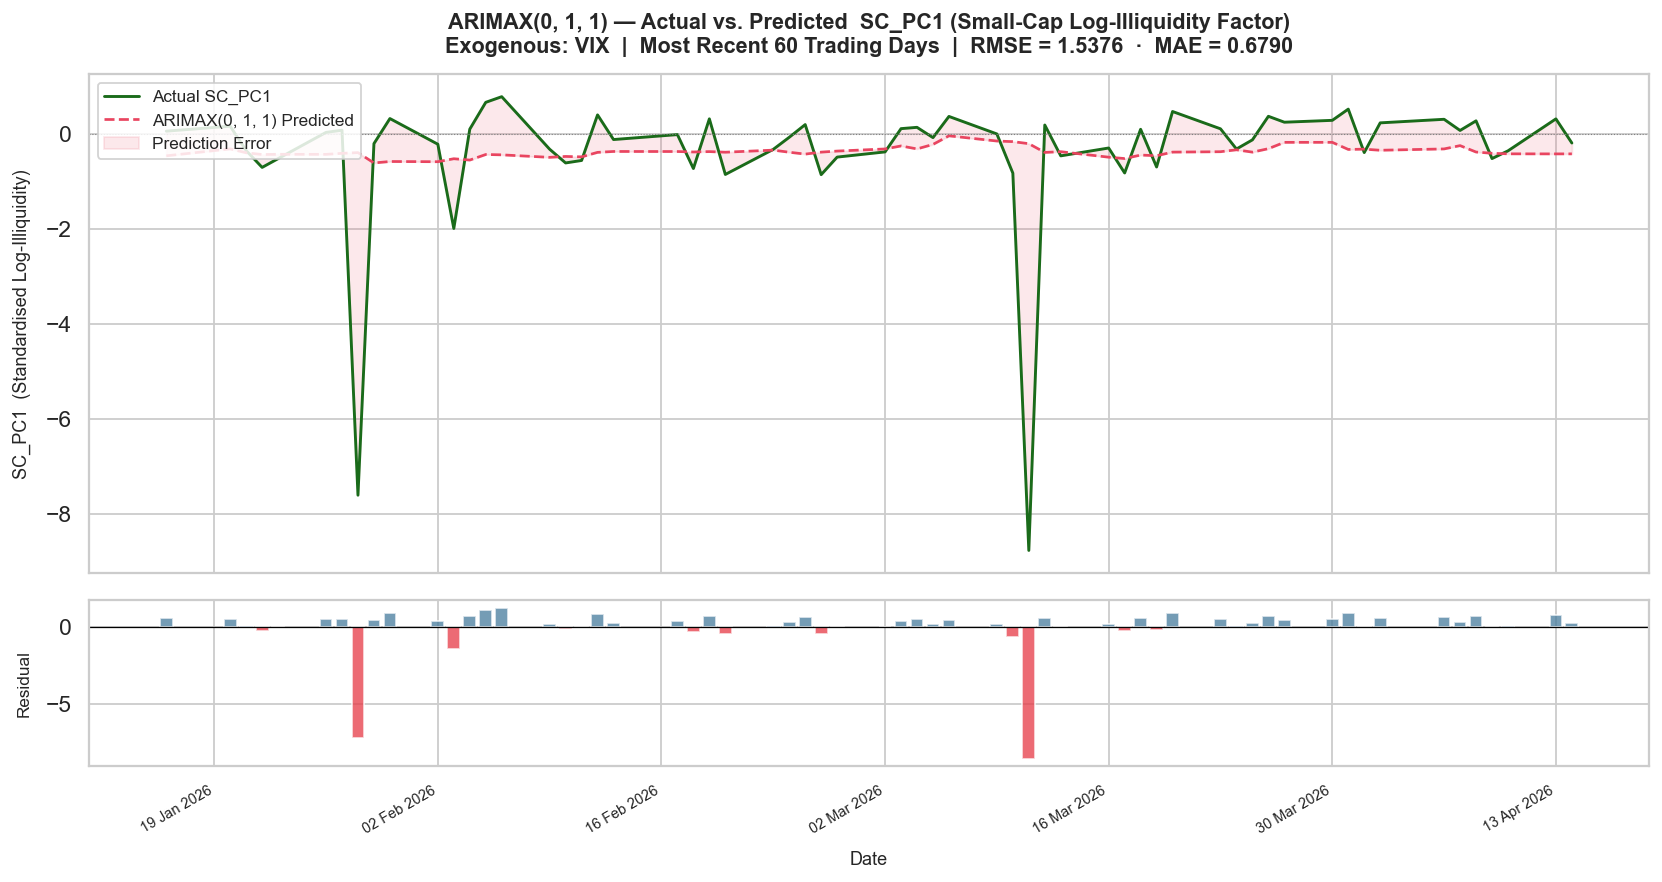

── ARIMAX Model Comparison: Mega-Cap vs Small-Cap (last 60 trading days) ──
                                                 Model Obs (total)  VIX coef       AIC  RMSE (60d)  MAE  (60d)
Mega-Cap (AAPL·MSFT·NVDA·GOOGL·AMZN)   ARIMAX(0, 1, 1)        1253    0.0537 3856.3293      0.7213      0.5709
Small-Cap (MARA·RIOT·SMCI·SOFI·RIVN)   ARIMAX(0, 1, 1)        1108    0.0307 3064.5369      1.5376      0.6790
[Δ Small − Mega]                      Δ (Small − Mega)               -0.0229 -791.7924      0.8163      0.1081

  Interpretation:
  ✖ Mega-cap RMSE is lower — the relationship may be non-linear or the 60-day window contains an atypical regime.


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — PCA on small-cap log-illiquidity scores → SC_PC1
# ══════════════════════════════════════════════════════════════════════════════
sc_clean    = illiq_scores_sc.dropna()
sc_scaler   = StandardScaler()
sc_X_scaled = sc_scaler.fit_transform(sc_clean)

sc_pca = PCA(n_components=len(SC_TICKERS))
sc_pca.fit(sc_X_scaled)

sc_pc1 = pd.Series(
    sc_pca.transform(sc_X_scaled)[:, 0],
    index=sc_clean.index,
    name="SC_PC1",
)

sc_explained = sc_pca.explained_variance_ratio_
print("── Small-Cap PCA Explained Variance ───────────────────────────────────")
for i, ev in enumerate(sc_explained, 1):
    print(f"  PC{i}: {ev:.2%}  {'◀ selected' if i == 1 else ''}")
print(f"\n  SC_PC1 captures {sc_explained[0]:.2%} of small-cap variance "
      f"(vs {explained[0]:.2%} for mega-caps).\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — ADF stationarity test on SC_PC1
# ══════════════════════════════════════════════════════════════════════════════
sc_adf_stat, sc_adf_pval, sc_adf_lags, sc_adf_nobs, sc_adf_crit, _ = adfuller(sc_pc1, autolag="AIC")

print("── ADF Test on SC_PC1 ─────────────────────────────────────────────────────────")
print(f"  Test Statistic : {sc_adf_stat:.4f}")
print(f"  p-value        : {sc_adf_pval:.4f}")
print(f"  Lags Used      : {sc_adf_lags}")
for level, cv in sc_adf_crit.items():
    print(f"  Critical Value ({level}): {cv:.4f}")
sc_stationary = sc_adf_pval < 0.05
print(f"\n  RESULT: {'Reject H₀ — SC_PC1 is STATIONARY.' if sc_stationary else 'Fail to reject H₀ — SC_PC1 is NON-STATIONARY.'}\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Align SC_PC1 with VIX and fit ARIMAX(0,1,1)
# Order is fixed to match the mega-cap optimal for a controlled comparison.
# ══════════════════════════════════════════════════════════════════════════════
FIXED_ORDER = (0, 1, 1)   # same as mega-cap optimal for a controlled comparison

sc_vix_exog = prices["VIX"].reindex(sc_pc1.index).ffill()
sc_ts = pd.concat([sc_pc1, sc_vix_exog], axis=1, join="inner").dropna()
sc_ts.columns = ["SC_PC1", "VIX"]

sc_endog = sc_ts["SC_PC1"]
sc_exog  = sc_ts[["VIX"]]

print(f"── Small-Cap ARIMAX{FIXED_ORDER} ───────────────────────────────────────────────────────────")
print(f"  Modelling window: {sc_ts.index[0].date()} → {sc_ts.index[-1].date()}")
print(f"  Observations    : {len(sc_ts)} (shorter than mega-cap due to RIVN IPO)\n")

sc_model = ARIMA(sc_endog, exog=sc_exog, order=FIXED_ORDER).fit()
print(sc_model.summary())

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Actual vs Predicted: last 60 trading days (small-cap)
# ══════════════════════════════════════════════════════════════════════════════
LOOKBACK = 60

sc_actual    = sc_endog.iloc[-LOOKBACK:]
sc_predicted = sc_model.fittedvalues.iloc[-LOOKBACK:]
sc_residuals = sc_actual - sc_predicted

sc_rmse = np.sqrt((sc_residuals ** 2).mean())
sc_mae  = sc_residuals.abs().mean()

# Re-derive mega-cap metrics on the same 60-day window for a clean comparison.
mega_actual    = endog.iloc[-LOOKBACK:]
mega_predicted = best_model.fittedvalues.iloc[-LOOKBACK:]
mega_residuals = mega_actual - mega_predicted
mega_rmse = np.sqrt((mega_residuals ** 2).mean())
mega_mae  = mega_residuals.abs().mean()

# ── Actual vs Predicted plot ─────────────────────────────────────────────────────────────────
fig, (ax_main, ax_resid) = plt.subplots(
    2, 1, figsize=(13, 7),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)

SC_LINE  = "#1a6b1a"   # dark green — matches small-cap colour scheme
SC_PRED  = "#e94560"   # red dashed  — consistent with mega-cap chart

ax_main.plot(sc_actual.index, sc_actual.values,
             color=SC_LINE, linewidth=1.6, label="Actual SC_PC1")
ax_main.plot(sc_predicted.index, sc_predicted.values,
             color=SC_PRED, linewidth=1.5, linestyle="--",
             label=f"ARIMAX{FIXED_ORDER} Predicted")
ax_main.fill_between(sc_actual.index, sc_actual.values, sc_predicted.values,
                     alpha=0.12, color=SC_PRED, label="Prediction Error")
ax_main.axhline(0, color="grey", linewidth=0.6, linestyle=":")

ax_main.set_title(
    f"ARIMAX{FIXED_ORDER} — Actual vs. Predicted  SC_PC1 (Small-Cap Log-Illiquidity Factor)\n"
    f"Exogenous: VIX  |  Most Recent {LOOKBACK} Trading Days  |  "
    f"RMSE = {sc_rmse:.4f}  ·  MAE = {sc_mae:.4f}",
    fontsize=12, fontweight="bold", pad=12,
)
ax_main.set_ylabel("SC_PC1  (Standardised Log-Illiquidity)", fontsize=10, labelpad=8)
ax_main.legend(loc="upper left", fontsize=9.5, framealpha=0.85)

ax_resid.bar(sc_residuals.index, sc_residuals.values,
             color=np.where(sc_residuals.values >= 0, "#457b9d", "#e63946"),
             width=0.8, alpha=0.75)
ax_resid.axhline(0, color="black", linewidth=0.7)
ax_resid.set_ylabel("Residual", fontsize=9.5, labelpad=8)
ax_resid.set_xlabel("Date", fontsize=10, labelpad=8)

ax_resid.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
ax_resid.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
plt.setp(ax_resid.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

fig.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Side-by-side RMSE / MAE comparison table
# ══════════════════════════════════════════════════════════════════════════════
comparison = pd.DataFrame(
    {
        "Universe"       : ["Mega-Cap (AAPL·MSFT·NVDA·GOOGL·AMZN)",
                            "Small-Cap (MARA·RIOT·SMCI·SOFI·RIVN)"],
        "Model"          : [f"ARIMAX{best_order}", f"ARIMAX{FIXED_ORDER}"],
        "Obs (total)"    : [len(endog), len(sc_endog)],
        "VIX coef"       : [best_model.params.get("VIX", float("nan")),
                            sc_model.params.get("VIX",  float("nan"))],
        "AIC"            : [best_model.aic, sc_model.aic],
        "RMSE (60d)"     : [mega_rmse, sc_rmse],
        "MAE  (60d)"     : [mega_mae,  sc_mae],
    }
).set_index("Universe")

# Improvement rows: negative Δ means small-cap model is better (lower error).
improvement = pd.DataFrame(
    {
        "Model"       : ["Δ (Small − Mega)"],
        "Obs (total)" : [""],
        "VIX coef"    : [comparison["VIX coef"].iloc[1]  - comparison["VIX coef"].iloc[0]],
        "AIC"         : [comparison["AIC"].iloc[1]        - comparison["AIC"].iloc[0]],
        "RMSE (60d)"  : [sc_rmse  - mega_rmse],
        "MAE  (60d)"  : [sc_mae   - mega_mae],
    },
    index=["[Δ Small − Mega]"]
)

full_table = pd.concat([comparison, improvement])

print("── ARIMAX Model Comparison: Mega-Cap vs Small-Cap (last 60 trading days) ──")
print(full_table.to_string(
    float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else x
))

print("\n  Interpretation:")
if sc_rmse < mega_rmse:
    pct = (mega_rmse - sc_rmse) / mega_rmse * 100
    print(f"  ✔ Small-cap RMSE is {pct:.1f}% lower — VIX explains more of the "
          f"small-cap liquidity factor, confirming the hypothesis.")
else:
    print(f"  ✖ Mega-cap RMSE is lower — the relationship may be non-linear "
          f"or the 60-day window contains an atypical regime.")

if comparison["VIX coef"].iloc[1] > comparison["VIX coef"].iloc[0]:
    print(f"  ✔ Small-cap VIX coefficient ({comparison['VIX coef'].iloc[1]:.4f}) "
          f"> mega-cap ({comparison['VIX coef'].iloc[0]:.4f}): "
          f"VIX has a stronger marginal impact on small-cap illiquidity.")
